In [27]:
%load_ext autoreload
%autoreload 2

# Section 2: International Comparison

We look at inflation in Denmark, Austria, Euro Area, and USA using data from Danmarks Statistik and FRED.

## Setup

In [30]:
from inflation_analysis import InflationAnalysis

# Initialize analysis
analysis = InflationAnalysis(start_date='2019-01-01')

## 2.1 CPI vs HICP

First we check if Danish CPI and HICP give similar results, so we can compare across countries.

In [31]:
# Get Danish CPI
cpi = analysis.get_danish_cpi()
print(f"CPI data: {len(cpi)} observations ({cpi.index.min().date()} to {cpi.index.max().date()})")

# Get HICP for all countries
hicp = analysis.get_hicp_data()
print(f"HICP data: {hicp.shape[0]} observations for {hicp.shape[1]} countries")

CPI data: 549 observations (1980-01-01 to 2025-09-01)
HICP data: 81 observations for 4 countries
HICP data: 81 observations for 4 countries


In [ ]:
# Compare CPI with HICP
comparison = analysis.compare_cpi_hicp()
comparison.head()

✓ Merged CPI and HICP data
Number of overlapping observations: 81
Date range: 2019-01-01 00:00:00 to 2025-09-01 00:00:00

First few rows:
            CPI_DST  HICP_FRED
date                          
2019-01-01    102.3      101.8
2019-02-01    102.8      102.3
2019-03-01    102.9      102.4
2019-04-01    103.2      102.7
2019-05-01    103.1      102.7

Last few rows:
            CPI_DST  HICP_FRED
date                          
2025-05-01    120.4      120.5
2025-06-01    120.7      120.9
2025-07-01    122.5      122.9
2025-08-01    121.7      122.0
2025-09-01    121.6      121.8


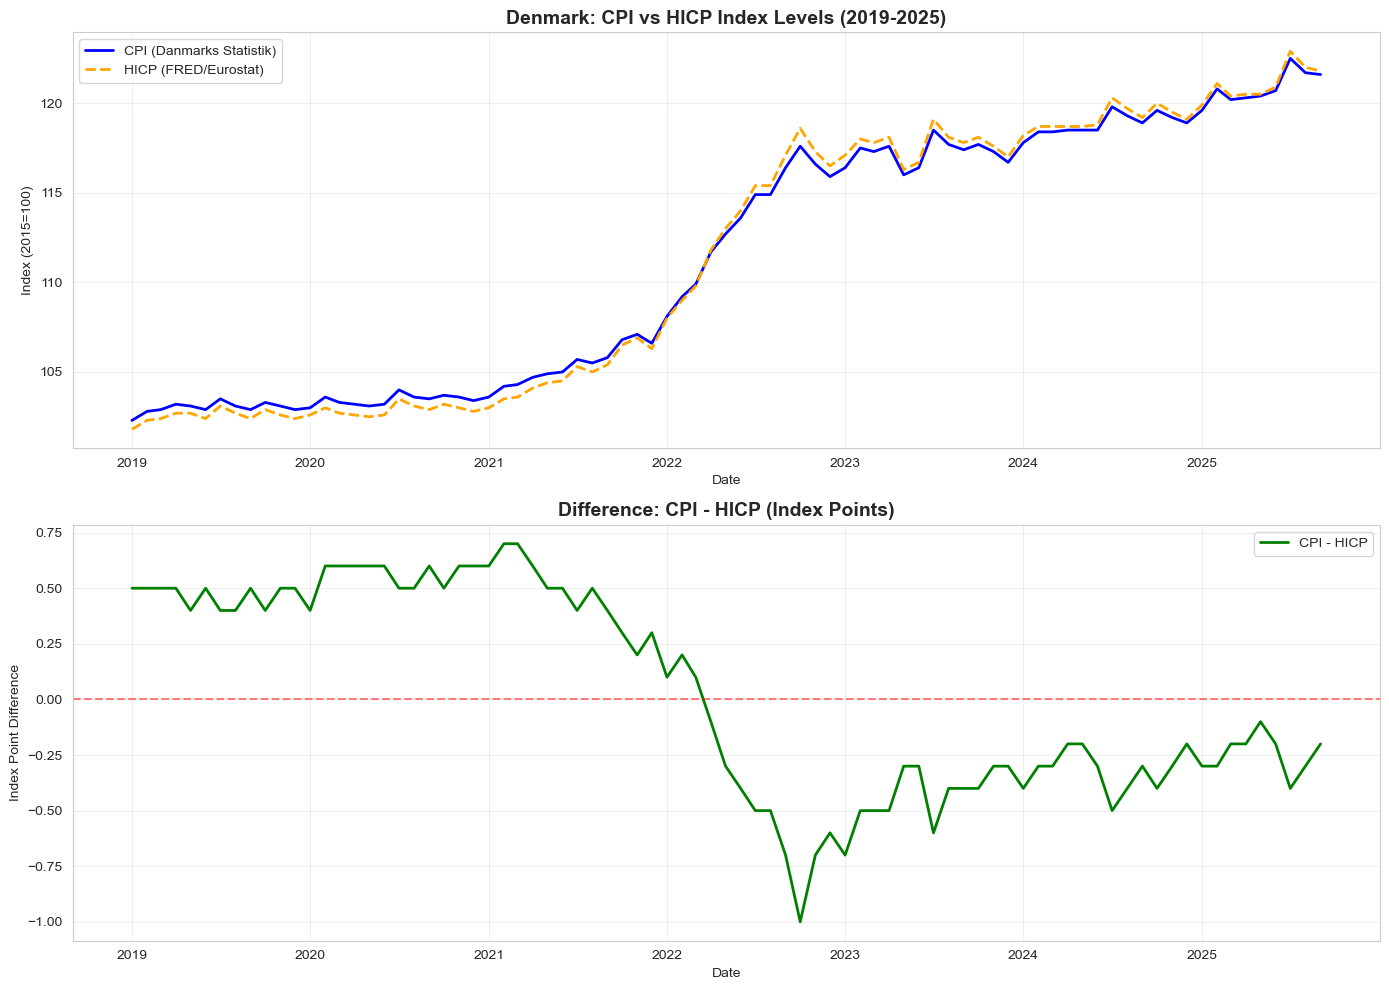

✓ CPI vs HICP comparison plot saved


In [ ]:
analysis.plot_cpi_hicp_comparison()

### Are they comparable?

In [32]:
comparability = analysis.analyze_comparability()

print(f"Correlation: {comparability['correlation']:.4f}")
print(f"Mean difference: {comparability['mean_abs_diff']:.2f} index points")
print(f"Relative difference: {comparability['mean_rel_diff_pct']:.2f}%")

Correlation: 0.9994
Mean difference: 0.42 index points
Relative difference: 0.38%


**Answer:** Yes, they track each other almost perfectly (correlation = 0.9994). The average difference is only 0.45 index points, so we can use HICP to compare inflation across countries.

## 2.2 Cross-Country Analysis

Now we compare inflation rates across the four countries since 2019.

In [ ]:
inflation = analysis.compute_inflation()

12-month inflation rates calculated


,Denmark,Austria,Euro_Area,United_States
DATE,,,,
2024-10-01,1.608806,1.807320,1.991808,2.571403
2024-11-01,1.615646,1.917560,2.229042,2.714168
2024-12-01,1.794872,2.134055,2.427028,2.872366
2025-01-01,1.438240,3.416290,2.500405,2.999413
2025-02-01,2.021904,3.421882,2.308002,2.814270
2025-03-01,1.432182,3.094244,2.155000,2.405585
2025-04-01,1.516428,3.254636,2.150623,2.333747
2025-05-01,1.516428,2.983853,1.876782,2.375934
2025-06-01,1.767677,3.220768,1.967602,2.672683


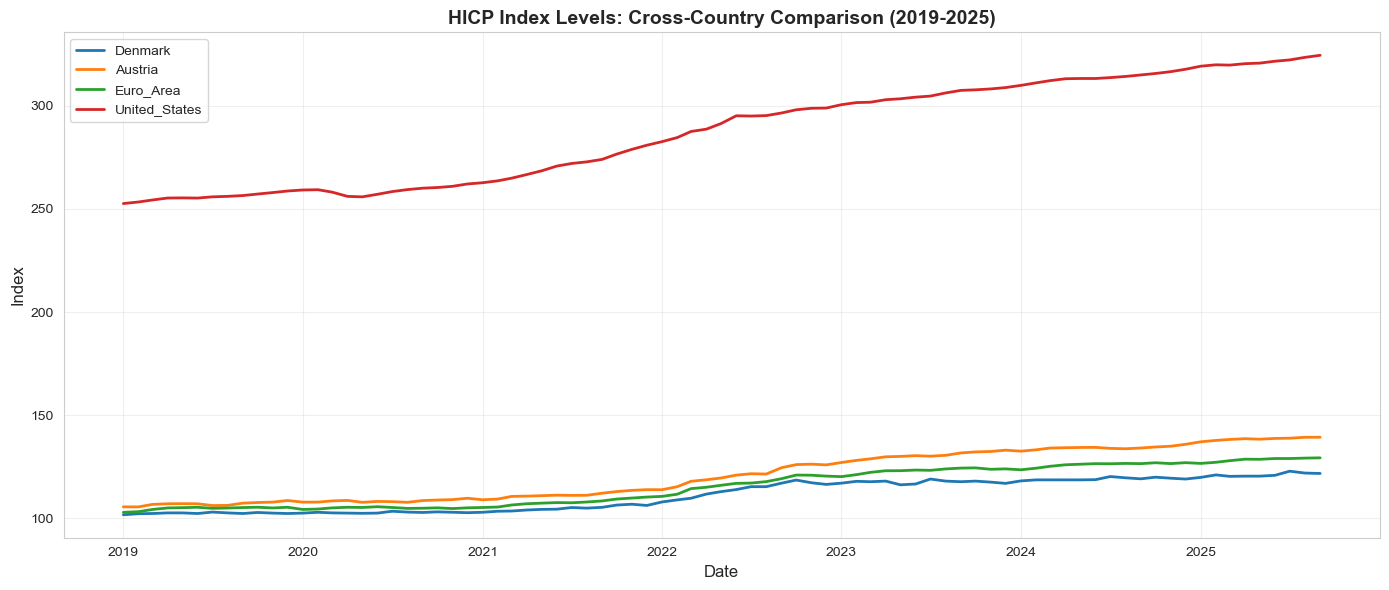

In [ ]:
analysis.plot_hicp_levels()

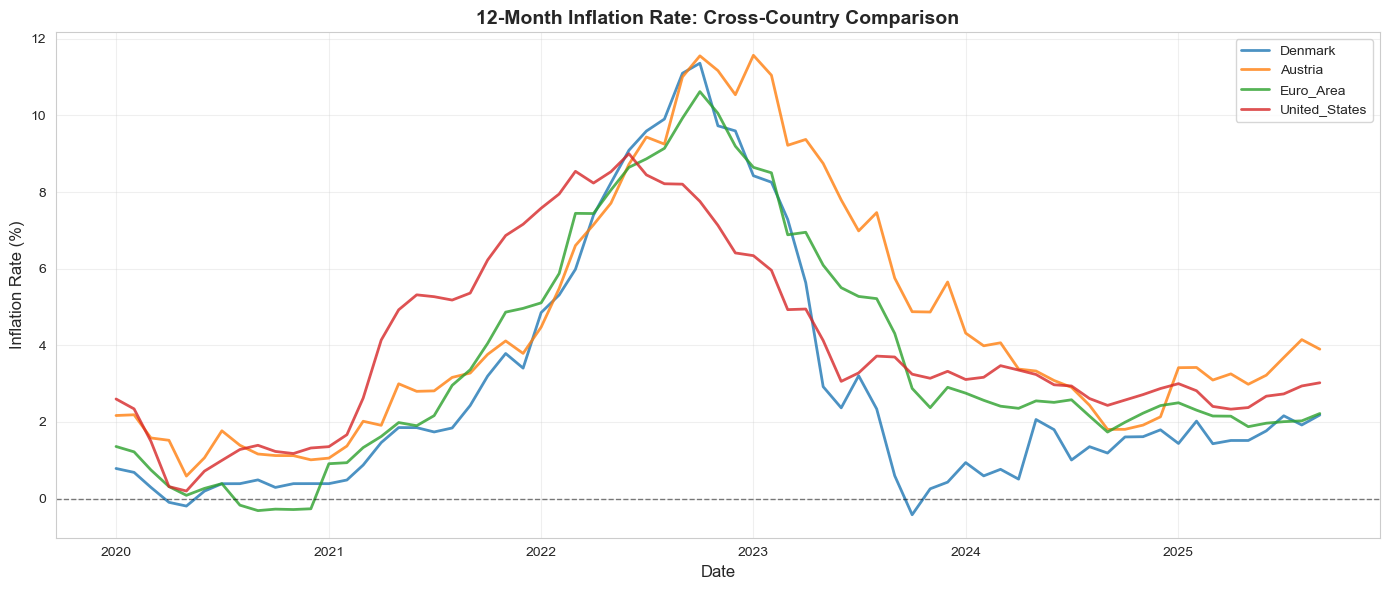

In [ ]:
analysis.plot_inflation_rates()

In [ ]:
stats = analysis.get_statistics_by_year()
print("Inflation Statistics by Year:")
stats.round(2)

Inflation Statistics by Year:


Denmark              Austria              Euro_Area               \
         min    max  mean     min    max  mean       min    max  mean   
year                                                                    
2019     NaN    NaN   NaN     NaN    NaN   NaN       NaN    NaN   NaN   
2020   -0.19   0.79  0.33    0.59   2.19  1.39     -0.31   1.36  0.26   
2021    0.39   3.79  1.94    1.06   4.11  2.76      0.91   4.96  2.59   
2022    4.85  11.36  8.51    4.48  11.55  8.59      5.11  10.62  8.36   
2023   -0.42   8.43  3.44    4.87  11.57  7.78      2.37   8.64  5.46   
2024    0.51   2.06  1.27    1.81   4.32  2.93      1.74   2.75  2.36   
2025    1.43   2.18  1.77    2.98   4.15  3.46      1.88   2.50  2.14   

     United_States              
               min   max  mean  
year                            
2019           NaN   NaN   NaN  
2020          0.20  2.60  1.25  
2021          1.36  7.16  4.67  
2022          6.41  9.00  8.00  
2023          3.06  6.34  4.15  
2024          2.43  3.47  2.95  
2025          2.33  3.02  2.70

In [ ]:
print("Overall Summary (2019-2025):")
inflation.describe().round(2)

Overall Summary Statistics (2019-2025):


,Denmark,Austria,Euro_Area,United_States
count,69.00,69.00,69.00,69.00
mean,2.93,4.53,3.59,4.01
std,3.20,3.12,2.98,2.37
min,-0.42,0.59,-0.31,0.20
25%,0.60,2.13,1.88,2.57
50%,1.77,3.42,2.43,3.17
75%,3.40,6.60,5.28,5.36
max,11.36,11.57,10.62,9.00


### What we see

**Timing:** USA got high inflation first (mid-2021), then Europe followed in late 2021. Everyone peaked around late 2022.

**Peak rates:** Austria had the highest (11.6% in Nov 2022), then Denmark (11.4%), Euro Area (10.6%), and USA (9.0%).

**Recovery:** Denmark came down fastest - only 2.2% by Sep 2025. USA also recovered well (2.2%), but Austria is still at 3.9%.

The pattern is pretty similar across all countries, probably because of energy prices and COVID effects. But Denmark and USA seem better at bringing inflation back down.